# AU Evaluation: M22911 2:00-2:30

This notebook summarizes infant PyAFAR AU occurrence scores for the 2:00-2:30 window of the original 30 FPS video. It is intentionally display-only: it shows numbers and visualizations inside the notebook and does not save new CSV, PNG, or other files.


## 1. Configuration

Set the input CSV, target time window, FPS, AU columns, and activation threshold. At 30 FPS, the 2:00-2:30 window corresponds to frames 3600-4500.


In [1]:
from pathlib import Path

# Input path. The expected file is M22911_30FPS_1Face.csv.
CSV_PATH = Path("./demo_vids/M22911_30FPS_1Face.csv")
FALLBACK_CSV_PATH = Path("./demo_vids/M22911_30FPS_1Fac.csv")

# Video timing
FPS = 30
START_SEC = 2 * 60       # 2:00
END_SEC = 2 * 60 + 30    # 2:30
START_FRAME = int(START_SEC * FPS)
END_FRAME = int(END_SEC * FPS)

# AU occurrence columns to analyze
AU_COLS = [
    "Occ_au_1", "Occ_au_2", "Occ_au_3", "Occ_au_4", "Occ_au_6",
    "Occ_au_9", "Occ_au_12", "Occ_au_20", "Occ_au_28",
]

# Threshold used for duration/bout metrics
ACTIVATION_THRESHOLD = 0.5

# Optional: require a bout to last at least this long to count as sustained.
# Keep at 0.0 to count all threshold crossings.
MIN_BOUT_DURATION_SEC = 0.0

print(f"Frame window: {START_FRAME} to {END_FRAME} inclusive")
print(f"Time window: {START_SEC:.1f}s to {END_SEC:.1f}s")


Frame window: 3600 to 4500 inclusive
Time window: 120.0s to 150.0s


## 2. Load And Filter Data

This cell loads the PyAFAR CSV, checks that the requested AU columns exist, and keeps only rows from 2:00 to 2:30.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

csv_path = CSV_PATH if CSV_PATH.exists() else FALLBACK_CSV_PATH
if not csv_path.exists():
    raise FileNotFoundError(f"Could not find {CSV_PATH} or fallback {FALLBACK_CSV_PATH}")

print(f"Loading: {csv_path}")
df = pd.read_csv(csv_path)

if "Frame" not in df.columns:
    raise ValueError("The CSV must contain a 'Frame' column.")

missing_aus = [col for col in AU_COLS if col not in df.columns]
if missing_aus:
    raise ValueError(f"Missing AU columns: {missing_aus}")

df["Frame"] = pd.to_numeric(df["Frame"], errors="coerce")
df = df.dropna(subset=["Frame"]).copy()
df["Frame"] = df["Frame"].astype(int)

window_df = df.loc[df["Frame"].between(START_FRAME, END_FRAME)].copy()
if window_df.empty:
    raise ValueError("No rows found in the requested frame/time window.")

for col in AU_COLS:
    window_df[col] = pd.to_numeric(window_df[col], errors="coerce")

window_df["Time_sec"] = window_df["Frame"] / FPS
window_df["Window_Time_sec"] = (window_df["Frame"] - START_FRAME) / FPS

au_df = window_df[["Frame", "Time_sec", "Window_Time_sec", *AU_COLS]].copy()

print(f"Full CSV shape: {df.shape}")
print(f"Filtered window shape: {window_df.shape}")
print(f"Observed frame range: {window_df['Frame'].min()} to {window_df['Frame'].max()}")
print(f"Observed duration: {len(window_df) / FPS:.2f} seconds, assuming one row per frame")
display(au_df.head())


Loading: demo_vids/M22911_30FPS_1Face.csv
Full CSV shape: (8717, 1420)
Filtered window shape: (901, 1422)
Observed frame range: 3600 to 4500
Observed duration: 30.03 seconds, assuming one row per frame


,Frame,Time_sec,Window_Time_sec,Occ_au_1,Occ_au_2,Occ_au_3,Occ_au_4,Occ_au_6,Occ_au_9,Occ_au_12,Occ_au_20,Occ_au_28
3600,3600,120.000000,0.000000,0.175372,0.207405,0.037389,0.021913,0.008527,0.004557,0.002061,0.015351,0.037320
3601,3601,120.033333,0.033333,0.153246,0.300485,0.035114,0.028726,0.008464,0.004181,0.001863,0.007716,0.013897
3602,3602,120.066667,0.066667,0.118296,0.320923,0.029726,0.017977,0.008359,0.000950,0.002672,0.005893,0.017116
3603,3603,120.100000,0.100000,0.106169,0.279806,0.064450,0.013900,0.017073,0.005143,0.005689,0.002920,0.031706
3604,3604,120.133333,0.133333,0.147440,0.240602,0.240150,0.011734,0.023582,0.039791,0.005229,0.021426,0.030802


In [15]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

## 3. Metric Definitions

For each AU, this notebook computes central tendency, variability, robust peaks, threshold activity, activation bouts, activation load, and simple frame-to-frame dynamics.


In [3]:
def summarize_bouts(values, threshold=0.5, fps=30, min_duration_sec=0.0):
    """Return count and duration summaries for consecutive frames above threshold."""
    active = np.asarray(values, dtype=float) > threshold
    if active.size == 0:
        return {
            "bout_count": 0,
            "mean_bout_duration_sec": 0.0,
            "max_bout_duration_sec": 0.0,
            "bout_durations_sec": [],
        }

    padded = np.r_[False, active, False]
    starts = np.flatnonzero((~padded[:-1]) & padded[1:])
    ends = np.flatnonzero(padded[:-1] & (~padded[1:]))
    durations = (ends - starts) / fps

    if min_duration_sec > 0:
        durations = durations[durations >= min_duration_sec]

    if len(durations) == 0:
        return {
            "bout_count": 0,
            "mean_bout_duration_sec": 0.0,
            "max_bout_duration_sec": 0.0,
            "bout_durations_sec": [],
        }

    return {
        "bout_count": int(len(durations)),
        "mean_bout_duration_sec": float(np.mean(durations)),
        "max_bout_duration_sec": float(np.max(durations)),
        "bout_durations_sec": durations.tolist(),
    }


def top_percent_mean(series, percent=5):
    s = pd.Series(series).dropna().astype(float)
    if s.empty:
        return np.nan
    n = max(1, int(np.ceil(len(s) * percent / 100)))
    return float(s.nlargest(n).mean())


## 4. Per-AU Summary Numbers

The main table below is useful as a compact feature summary for the 30-second window. No files are written; the table is displayed only.


In [16]:
summary_rows = []
bout_rows = []

for au in AU_COLS:
    s = au_df[au].astype(float)
    valid = s.dropna()
    diffs = valid.diff().dropna()
    active = s > ACTIVATION_THRESHOLD
    bout_info = summarize_bouts(
        s.to_numpy(),
        threshold=ACTIVATION_THRESHOLD,
        fps=FPS,
        min_duration_sec=MIN_BOUT_DURATION_SEC,
    )

    summary_rows.append({
        "AU": au,
        "n_frames": int(valid.shape[0]),
        "duration_sec": float(valid.shape[0] / FPS),
        "mean": float(valid.mean()) if not valid.empty else np.nan,
        "median": float(valid.median()) if not valid.empty else np.nan,
        "std": float(valid.std(ddof=1)) if valid.shape[0] > 1 else 0.0,
        "min": float(valid.min()) if not valid.empty else np.nan,
        "q25": float(valid.quantile(0.25)) if not valid.empty else np.nan,
        "q50": float(valid.quantile(0.50)) if not valid.empty else np.nan,
        "q75": float(valid.quantile(0.75)) if not valid.empty else np.nan,
        "iqr": float(valid.quantile(0.75) - valid.quantile(0.25)) if not valid.empty else np.nan,
        "q90": float(valid.quantile(0.90)) if not valid.empty else np.nan,
        "q95": float(valid.quantile(0.95)) if not valid.empty else np.nan,
        "max": float(valid.max()) if not valid.empty else np.nan,
        "top_5pct_mean": top_percent_mean(valid, percent=5),
        "proportion_gt_0_5": float(active.mean()),
        "duration_gt_0_5_sec": float(active.sum() / FPS),
        "auc_likelihood_seconds": float(valid.sum() / FPS),
        "mean_abs_frame_change": float(diffs.abs().mean()) if not diffs.empty else 0.0,
        "max_abs_frame_change": float(diffs.abs().max()) if not diffs.empty else 0.0,
        "bout_count_gt_0_5": bout_info["bout_count"],
        "mean_bout_duration_sec": bout_info["mean_bout_duration_sec"],
        "max_bout_duration_sec": bout_info["max_bout_duration_sec"],
    })

    for j, duration in enumerate(bout_info["bout_durations_sec"], start=1):
        bout_rows.append({"AU": au, "bout_number": j, "duration_sec": duration})

summary_df = pd.DataFrame(summary_rows).sort_values("mean", ascending=False).reset_index(drop=True)
bout_df = pd.DataFrame(bout_rows)

display(summary_df)


,AU,n_frames,duration_sec,mean,median,std,min,q25,q50,q75,iqr,q90,q95,max,top_5pct_mean,proportion_gt_0_5,duration_gt_0_5_sec,auc_likelihood_seconds,mean_abs_frame_change,max_abs_frame_change,bout_count_gt_0_5,mean_bout_duration_sec,max_bout_duration_sec
0,Occ_au_1,901,30.033333,0.571052,0.677155,0.350229,0.0,0.175139,0.677155,0.897825,0.722686,0.962981,0.979749,0.989969,0.984310,0.603774,18.133333,17.150587,0.075767,0.988167,43,0.421705,9.833333
1,Occ_au_2,901,30.033333,0.481625,0.487243,0.322924,0.0,0.160972,0.487243,0.791223,0.630251,0.907469,0.937863,0.983054,0.954326,0.493896,14.833333,14.464797,0.093116,0.807742,54,0.274691,7.000000
2,Occ_au_3,901,30.033333,0.461316,0.474784,0.349054,0.0,0.082111,0.474784,0.808451,0.726340,0.905103,0.934665,0.979333,0.953044,0.489456,14.700000,13.854859,0.081905,0.568091,34,0.432353,3.966667
3,Occ_au_20,901,30.033333,0.386428,0.184068,0.394730,0.0,0.016161,0.184068,0.846271,0.830110,0.942756,0.960445,0.987809,0.972345,0.396226,11.900000,11.605711,0.057068,0.610903,28,0.425000,3.300000
4,Occ_au_6,901,30.033333,0.352772,0.112040,0.384453,0.0,0.017813,0.112040,0.815331,0.797519,0.923253,0.949600,0.987700,0.962460,0.357381,10.733333,10.594916,0.048811,0.546035,12,0.894444,6.266667
5,Occ_au_4,901,30.033333,0.200061,0.074202,0.260718,0.0,0.010657,0.074202,0.302059,0.291402,0.651986,0.817864,0.977048,0.890452,0.154273,4.633333,6.008486,0.064920,0.599782,26,0.178205,1.533333
6,Occ_au_9,901,30.033333,0.128174,0.002500,0.243092,0.0,0.000198,0.002500,0.111490,0.111292,0.574560,0.774800,0.981230,0.868201,0.118757,3.566667,3.849495,0.051117,0.716884,22,0.162121,0.866667
7,Occ_au_12,901,30.033333,0.072457,0.010104,0.143493,0.0,0.001685,0.010104,0.072665,0.070980,0.206459,0.364721,0.929478,0.590446,0.032186,0.966667,2.176136,0.033620,0.599476,11,0.087879,0.333333
8,Occ_au_28,901,30.033333,0.039685,0.015120,0.075377,0.0,0.006487,0.015120,0.035102,0.028615,0.090492,0.185559,0.662862,0.309201,0.004440,0.133333,1.191881,0.027959,0.644189,4,0.033333,0.033333


## Metric Interpretation Guide

The previous code cell creates `summary_df`, which is the main per-AU feature table. Each row is one AU, and each column is one summary metric for the 2:00-2:30 window.

### Basic Window Information

- `AU`: The facial Action Unit column being summarized, for example `Occ_au_12`.
- `n_frames`: Number of valid AU samples in this time window. At 30 FPS, a complete 30-second window should be about 901 frames if both endpoints are included.
- `duration_sec`: Approximate analyzed duration in seconds, computed as `n_frames / FPS`.

### Central Tendency And Spread

- `mean`: Average AU likelihood across the whole window. This is a good general measure of how active the AU was overall.
- `median`: Middle AU likelihood. This is more robust than the mean if the AU has brief spikes.
- `std`: Standard deviation. Higher values mean the AU signal varies more over time.
- `min` and `max`: Lowest and highest observed AU likelihood. `max` is useful as a peak indicator, but it can be sensitive to one-frame noise.

### Distribution Shape

- `q25`, `q50`, `q75`: The 25th, 50th, and 75th percentiles. These describe the distribution without assuming normality.
- `iqr`: Interquartile range, calculated as `q75 - q25`. Higher IQR means the middle half of the AU values is more spread out.
- `q90` and `q95`: High-end percentiles. These are useful robust peak metrics because they ignore the most extreme few frames.

### Robust Peak Activation

- `top_5pct_mean`: Mean of the highest 5% AU likelihood values. This is often better than raw `max` for psychological analysis because it captures strong activation while reducing sensitivity to a single noisy frame.

### Threshold-Based Activity

These metrics use `ACTIVATION_THRESHOLD = 0.5` by default.

- `proportion_gt_0_5`: Fraction of frames where the AU likelihood is greater than 0.5.
- `duration_gt_0_5_sec`: Number of seconds where the AU likelihood is greater than 0.5. This is often easier to interpret than a proportion.

### Activation Load

- `auc_likelihood_seconds`: Area under the AU likelihood curve, approximated as `sum(AU likelihood) / FPS`. This combines intensity and duration: a high value can come from sustained moderate activation or shorter strong activation.

### Dynamics

- `mean_abs_frame_change`: Average absolute frame-to-frame change. Larger values suggest more movement or fluctuation in the AU signal.
- `max_abs_frame_change`: Largest frame-to-frame jump. Useful for detecting abrupt changes, but it may also reflect noise.

### Bout Metrics

A bout is a consecutive run of frames where an AU is above the activation threshold.

- `bout_count_gt_0_5`: Number of separate activation episodes above 0.5.
- `mean_bout_duration_sec`: Average duration of those activation episodes.
- `max_bout_duration_sec`: Longest continuous activation episode.

### How To Use The Following Cells

- The next cell displays `bout_df`, which expands the bout metrics into one row per AU activation episode.
- The time-series plot shows when each AU rises, falls, or overlaps with other AUs.
- The feature comparison bar plots make it easy to compare AUs by mean activation, robust peak activation, active duration, and AUC.
- The correlation table shows whether AU likelihood traces rise and fall together.
- The co-activation table shows how often AU pairs are simultaneously above 0.5.


## 6. AU Time-Series Visualization

This plot shows the AU likelihood traces across the selected 30-second window.


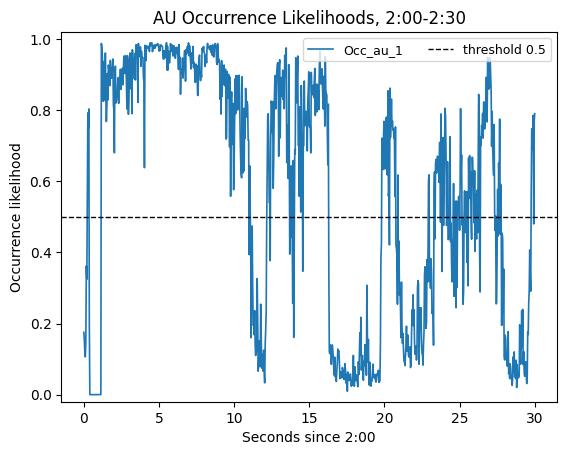

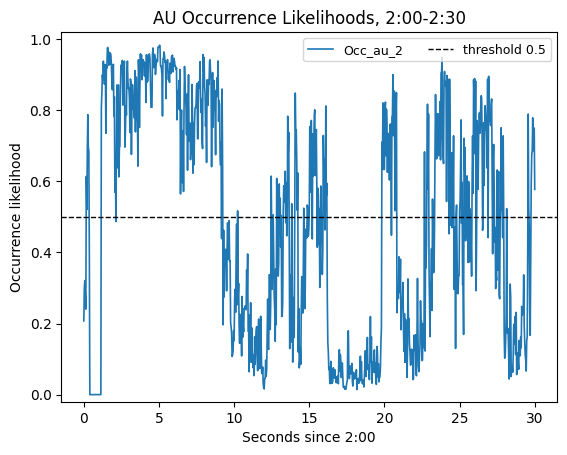

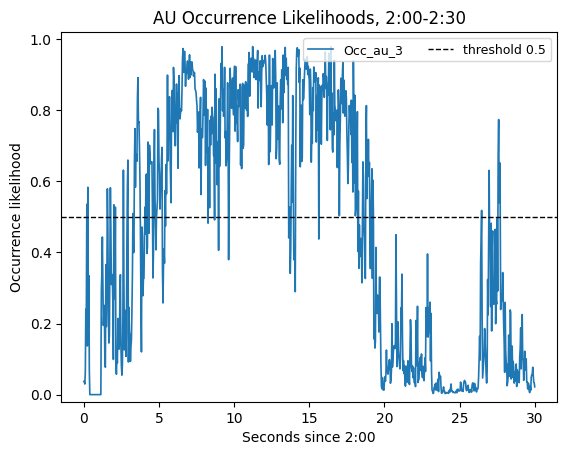

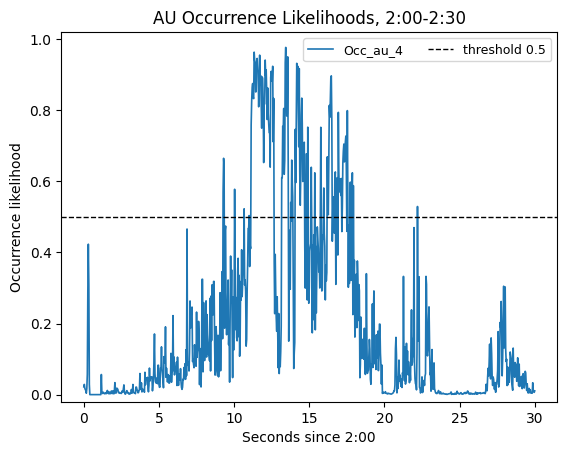

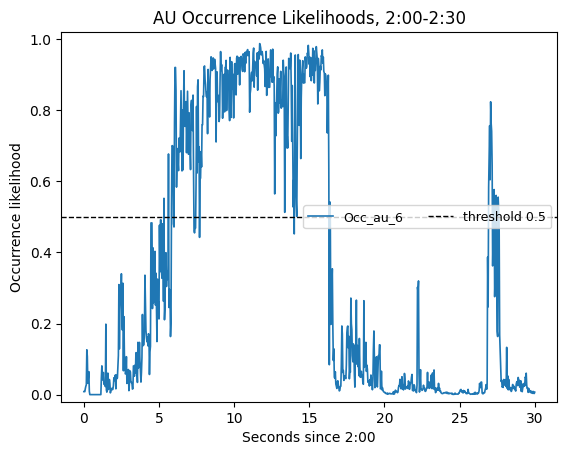

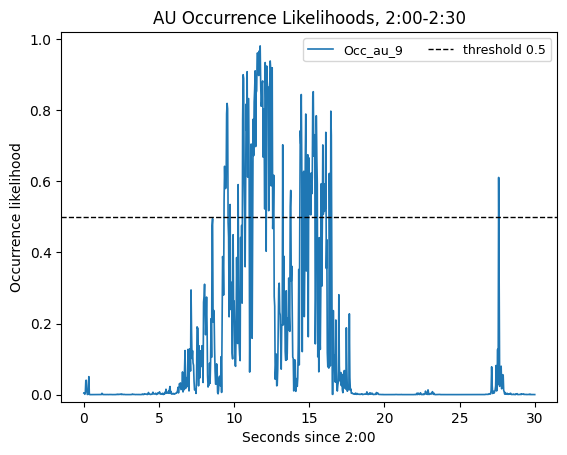

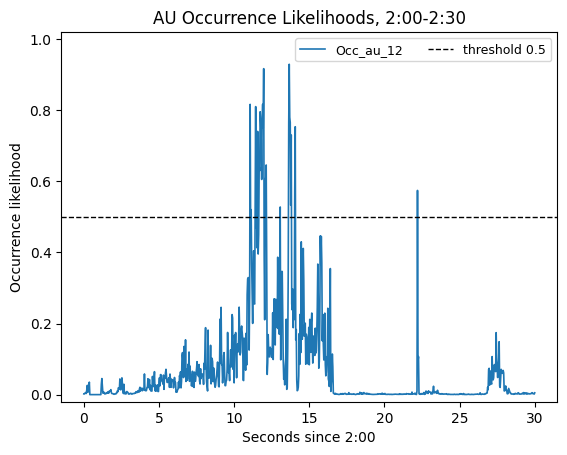

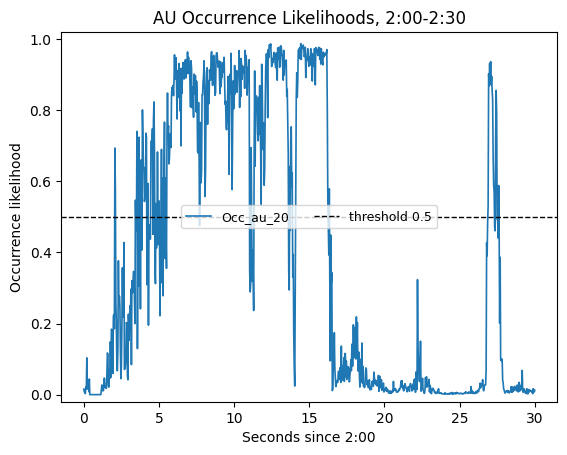

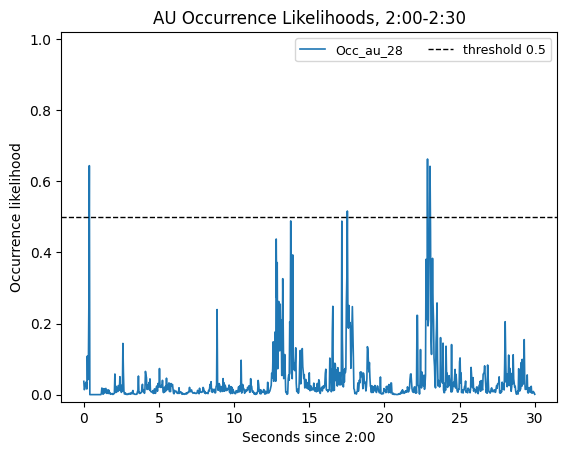

In [12]:
# fig, ax = plt.subplots(figsize=(14, 6))
for au in AU_COLS:
    plt.plot(au_df["Window_Time_sec"], au_df[au], linewidth=1.2, label=au)

    plt.axhline(ACTIVATION_THRESHOLD, color="black", linestyle="--", linewidth=1.0, label=f"threshold {ACTIVATION_THRESHOLD}")
    plt.title("AU Occurrence Likelihoods, 2:00-2:30")
    plt.xlabel("Seconds since 2:00")
    plt.ylabel("Occurrence likelihood")
    plt.ylim(-0.02, 1.02)
    plt.legend(ncol=3, fontsize=9)
    plt.show()


## 7. Feature Comparison Visualizations

These bar plots compare AUs on psychologically interpretable summaries: mean activation, robust peak activation, active duration, and total activation load.


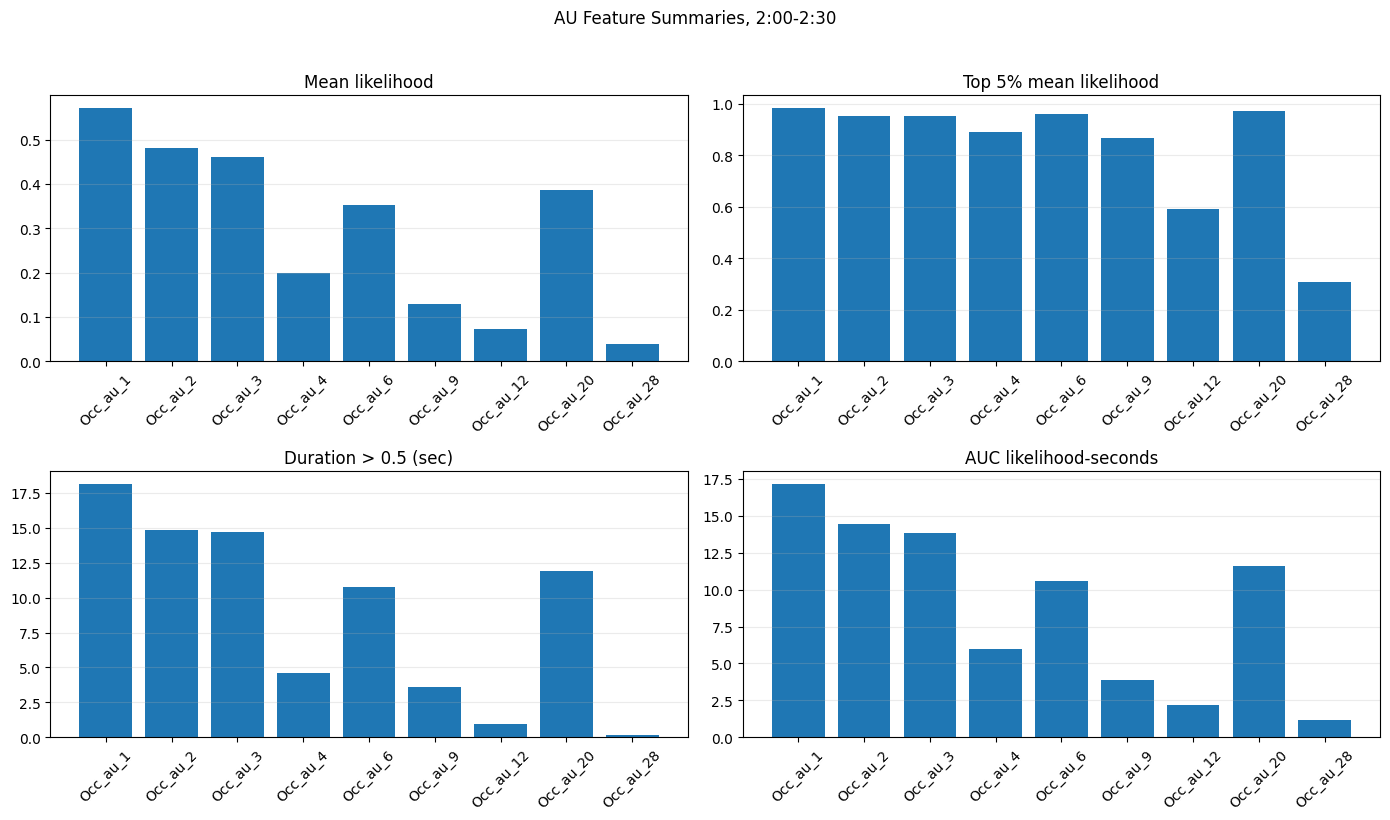

In [7]:
plot_metrics = [
    ("mean", "Mean likelihood"),
    ("top_5pct_mean", "Top 5% mean likelihood"),
    ("duration_gt_0_5_sec", "Duration > 0.5 (sec)"),
    ("auc_likelihood_seconds", "AUC likelihood-seconds"),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.ravel()
plot_df = summary_df.set_index("AU").loc[AU_COLS].reset_index()

for ax, (metric, title) in zip(axes, plot_metrics):
    ax.bar(plot_df["AU"], plot_df[metric])
    ax.set_title(title)
    ax.tick_params(axis="x", rotation=45)
    ax.grid(axis="y", alpha=0.25)

fig.suptitle("AU Feature Summaries, 2:00-2:30", y=1.02)
fig.tight_layout()
plt.show()


## 8. AU Co-Activation And Correlation Numbers

The first table shows Pearson correlations between AU likelihood traces. The second table shows the proportion of frames where each AU pair is simultaneously above 0.5.


In [8]:
corr_df = au_df[AU_COLS].corr(method="pearson")
coactivation = pd.DataFrame(index=AU_COLS, columns=AU_COLS, dtype=float)
active_df = au_df[AU_COLS] > ACTIVATION_THRESHOLD

for au_i in AU_COLS:
    for au_j in AU_COLS:
        coactivation.loc[au_i, au_j] = float((active_df[au_i] & active_df[au_j]).mean())

print("Pearson correlations:")
display(corr_df.round(3))

print(f"Co-activation proportions above {ACTIVATION_THRESHOLD}:")
display(coactivation.round(3))


Pearson correlations:


,Occ_au_1,Occ_au_2,Occ_au_3,Occ_au_4,Occ_au_6,Occ_au_9,Occ_au_12,Occ_au_20,Occ_au_28
Occ_au_1,1.000,0.806,0.329,-0.128,0.441,0.071,0.025,0.586,-0.170
Occ_au_2,0.806,1.000,0.002,-0.379,0.055,-0.219,-0.175,0.222,-0.160
Occ_au_3,0.329,0.002,1.000,0.644,0.781,0.552,0.441,0.787,-0.003
Occ_au_4,-0.128,-0.379,0.644,1.000,0.568,0.683,0.569,0.448,0.114
Occ_au_6,0.441,0.055,0.781,0.568,1.000,0.690,0.613,0.910,-0.053
Occ_au_9,0.071,-0.219,0.552,0.683,0.690,1.000,0.621,0.580,-0.044
Occ_au_12,0.025,-0.175,0.441,0.569,0.613,0.621,1.000,0.446,0.044
Occ_au_20,0.586,0.222,0.787,0.448,0.910,0.580,0.446,1.000,-0.102
Occ_au_28,-0.170,-0.160,-0.003,0.114,-0.053,-0.044,0.044,-0.102,1.000


Co-activation proportions above 0.5:


,Occ_au_1,Occ_au_2,Occ_au_3,Occ_au_4,Occ_au_6,Occ_au_9,Occ_au_12,Occ_au_20,Occ_au_28
Occ_au_1,0.604,0.447,0.361,0.069,0.306,0.079,0.009,0.354,0.000
Occ_au_2,0.447,0.494,0.239,0.027,0.181,0.028,0.004,0.231,0.001
Occ_au_3,0.361,0.239,0.489,0.151,0.333,0.117,0.024,0.357,0.001
Occ_au_4,0.069,0.027,0.151,0.154,0.114,0.070,0.023,0.105,0.001
Occ_au_6,0.306,0.181,0.333,0.114,0.357,0.115,0.031,0.336,0.000
Occ_au_9,0.079,0.028,0.117,0.070,0.115,0.119,0.021,0.113,0.000
Occ_au_12,0.009,0.004,0.024,0.023,0.031,0.021,0.032,0.024,0.000
Occ_au_20,0.354,0.231,0.357,0.105,0.336,0.113,0.024,0.396,0.000
Occ_au_28,0.000,0.001,0.001,0.001,0.000,0.000,0.000,0.000,0.004


## 9. AU Co-Activation And Correlation Visualizations

These heatmaps make the correlation and co-activation structure easier to scan.


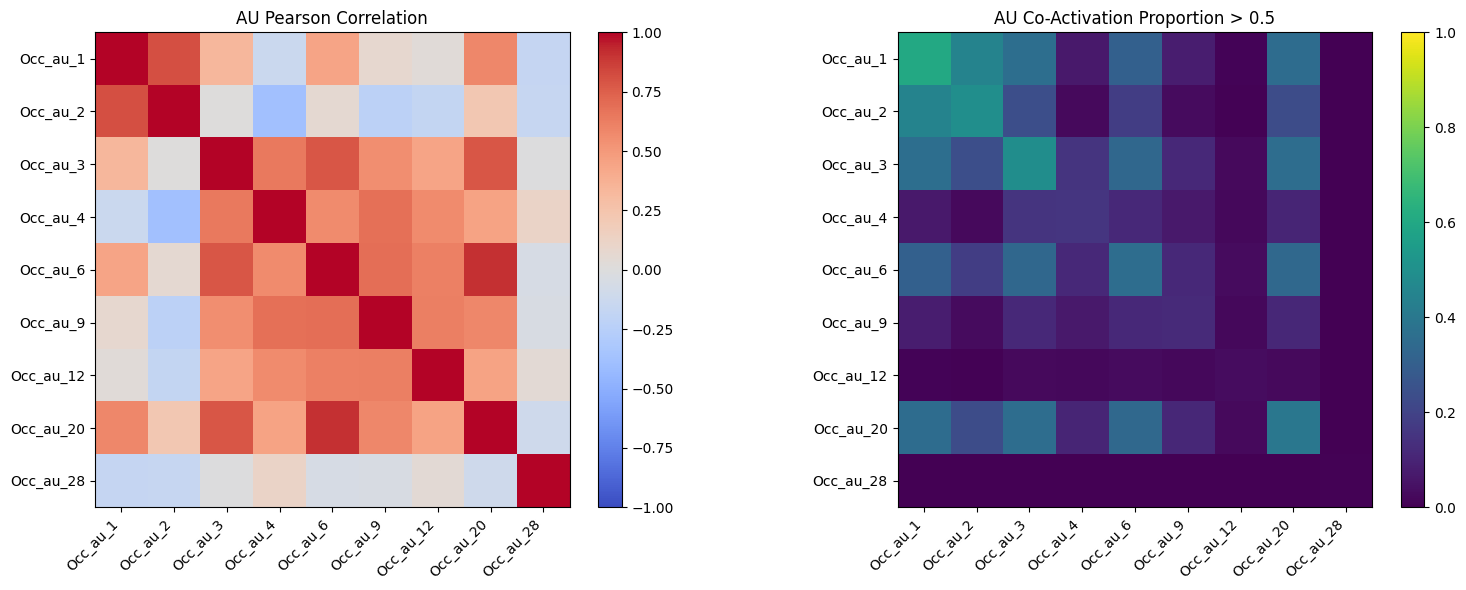

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

im0 = axes[0].imshow(corr_df, vmin=-1, vmax=1, cmap="coolwarm")
axes[0].set_title("AU Pearson Correlation")
axes[0].set_xticks(range(len(AU_COLS)), AU_COLS, rotation=45, ha="right")
axes[0].set_yticks(range(len(AU_COLS)), AU_COLS)
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(coactivation, vmin=0, vmax=1, cmap="viridis")
axes[1].set_title(f"AU Co-Activation Proportion > {ACTIVATION_THRESHOLD}")
axes[1].set_xticks(range(len(AU_COLS)), AU_COLS, rotation=45, ha="right")
axes[1].set_yticks(range(len(AU_COLS)), AU_COLS)
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

fig.tight_layout()
plt.show()


## 10. Suggested Features For Statistical Analysis

For participant-level or condition-level models, good candidate features from `summary_df` are `mean`, `top_5pct_mean`, `duration_gt_0_5_sec`, `bout_count_gt_0_5`, `mean_bout_duration_sec`, and `auc_likelihood_seconds`. Use `max` carefully because it can be dominated by one noisy frame.
